<a href="https://colab.research.google.com/github/kartik0920/Hands-on-Machine-learning/blob/Main/chapter_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Linear Regression

In [99]:
import numpy as np

In [100]:
x=np.random.rand(100,1)
y=4+3*x+np.random.rand(100,1)

In [101]:
import matplotlib.pyplot as plt

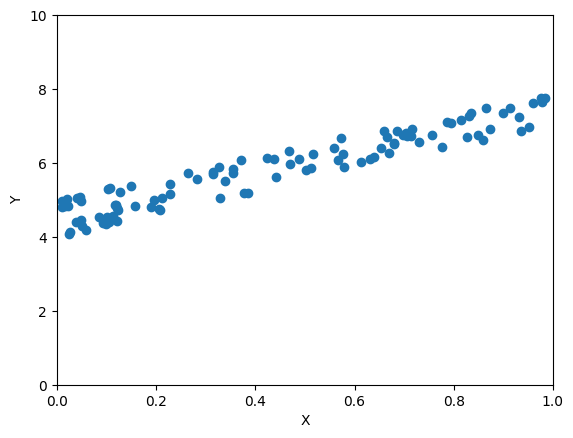

In [102]:
plt.plot(x,y,'o',)
plt.xlabel('X')
plt.ylabel('Y')
plt.axis([0,1,0,10])
plt.show()

In [103]:
x_b=np.c_[np.ones((100,1)),x]
theta_best=np.linalg.inv(x_b.T.dot(x_b)).dot(x_b.T).dot(y)
theta_best

array([[4.49592643],
       [3.06070202]])

In [104]:
x_new=np.array([[0],[2]])
x_new_b=np.c_[np.ones((2,1)),x_new]
y_pred=x_new_b.dot(theta_best)
y_pred

array([[ 4.49592643],
       [10.61733046]])

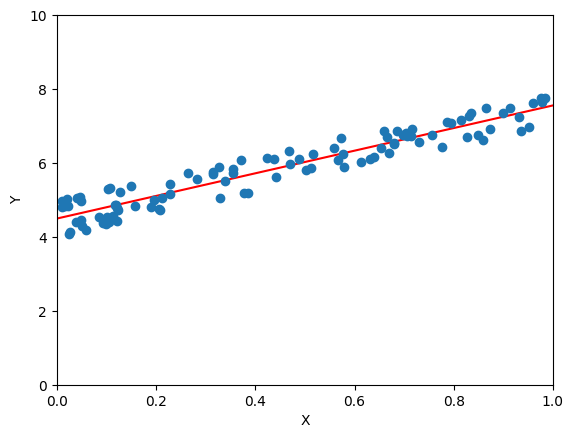

In [105]:
plt.plot(x_new,y_pred,'r-')
plt.plot(x,y,'o',)
plt.xlabel('X')
plt.ylabel('Y')
# plt.figure(figsize=(50,25))
plt.axis([0,1,0,10])
plt.show()

using sklitlearn

In [106]:
from sklearn.linear_model import LinearRegression
lin_reg=LinearRegression()
lin_reg.fit(x,y)

LinearRegression()

In [107]:
lin_reg.intercept_, lin_reg.coef_

(array([4.49592643]), array([[3.06070202]]))

In [108]:
lin_reg.predict(x_new)

array([[ 4.49592643],
       [10.61733046]])

In [109]:
theta_best_svd,residuals,rank,s=np.linalg.lstsq(x_b,y,rcond=1e-6)
theta_best_svd

array([[4.49592643],
       [3.06070202]])

##Gradeint Descent and Linear Regression

Batch Gradient Descent

In [110]:
eta=0.1 #learning rate or (n)
n_iterations=1000
m=100

theta=np.random.randn(2,1)

for i in range( n_iterations):
  gradient=(2/m)*x_b.T.dot(x_b.dot(theta)-y)
  theta=theta-eta*gradient

theta

array([[4.49592651],
       [3.06070185]])

stochastic Gradient Descent

In [111]:
n_epochs=50
t0,t1=5,50

def learning_schedule(t):
  return t0/(t+t1)


theta=np.random.randn(2,1)
for epoch in range(n_epochs):
  for i in range(m):
    random_index = np.random.randint(m)
    xi = x_b[random_index:random_index+1]
    yi = y[random_index:random_index+1]
    gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
    eta = learning_schedule(epoch * m + i)
    theta = theta - eta * gradients

In [112]:
theta

array([[4.48307234],
       [3.08706357]])

In [113]:
from sklearn.linear_model import SGDRegressor

sgd_reg=SGDRegressor(max_iter=1000,eta0=0.1,tol=1e-3,penalty=None)

sgd_reg.fit(x,y)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SGDRegressor(eta0=0.1, penalty=None)

In [114]:
sgd_reg.intercept_,sgd_reg.coef_

(array([4.57047301]), array([2.9483985]))

#Polynomial Regression

In [115]:
x=6* np.random.rand(100,1)-3
y=0.5*x**2+2+x+np.random.rand(100,1)

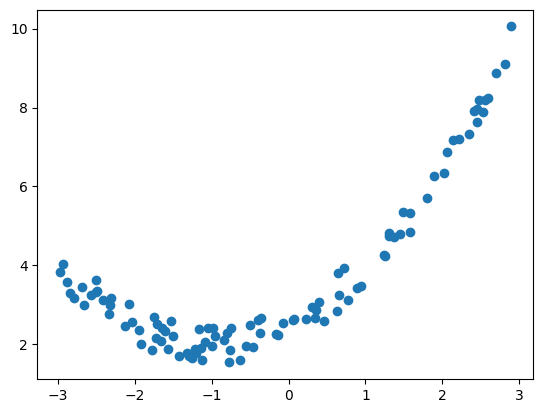

In [116]:
plt.plot(x,y,'o')
plt.show()

In [117]:
from sklearn.preprocessing import PolynomialFeatures
poly_features=PolynomialFeatures(degree=2,include_bias=False)
x_poly=poly_features.fit_transform(x)
x_poly[0]

array([0.07582563, 0.00574953])

In [118]:
lin_reg=LinearRegression()
lin_reg.fit(x_poly,y)

LinearRegression()

In [119]:
lin_reg.intercept_,lin_reg.coef_

(array([2.47041905]), array([[0.9901584 , 0.50001175]]))

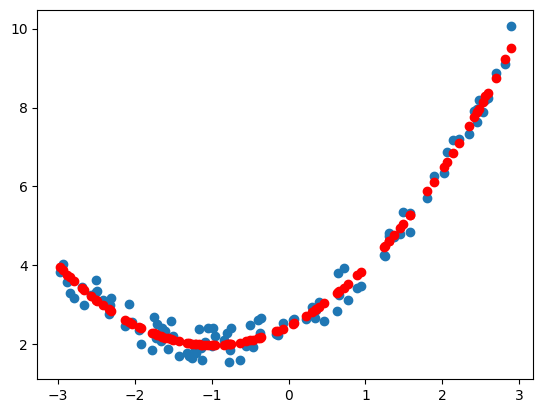

In [120]:
plt.plot(x,y,'o')
plt.plot(x,lin_reg.predict(x_poly),'ro',linewidth=1)
plt.show()

#Ridge lasso and elastic net regression

In [121]:
from sklearn.linear_model import Ridge

In [122]:
ridge_reg=Ridge(alpha=1,solver="cholesky")
ridge_reg.fit(x,y)

Ridge(alpha=1, solver='cholesky')

In [123]:
ridge_reg.predict([[1.5]])

array([5.3137324])

In [124]:
sgd_reg=SGDRegressor(penalty="l2")
sgd_reg.fit(x,y.ravel())

SGDRegressor()

In [125]:
sgd_reg.predict([[1.5]])

array([5.30550549])

In [126]:
from sklearn.linear_model import Lasso

In [127]:
lasso_reg=Lasso(alpha=0.1)
lasso_reg.fit(x,y)

Lasso(alpha=0.1)

In [128]:
lasso_reg.predict([[1.5]])

array([5.2568176])

In [129]:
from sklearn.linear_model import ElasticNet


In [130]:
elastic_net_reg=ElasticNet(alpha=0.1,l1_ratio=0.5)
elastic_net_reg.fit(x,y)

ElasticNet(alpha=0.1)

In [131]:
elastic_net_reg.predict([[1.5]])

array([5.26005821])

#Logistic Regression

In [132]:
from sklearn import datasets

In [133]:
iris=datasets.load_iris()
list(iris.keys())

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [134]:
x=iris["data"][:,3:]
y=(iris["target"]==2).astype(int)


In [135]:
from sklearn.linear_model import LogisticRegression
log_reg=LogisticRegression()
log_reg.fit(x,y)

LogisticRegression()

In [136]:
x_new=np.linspace(0,3,1000).reshape(-1,1)
y_prob=log_reg.predict_proba(x_new)

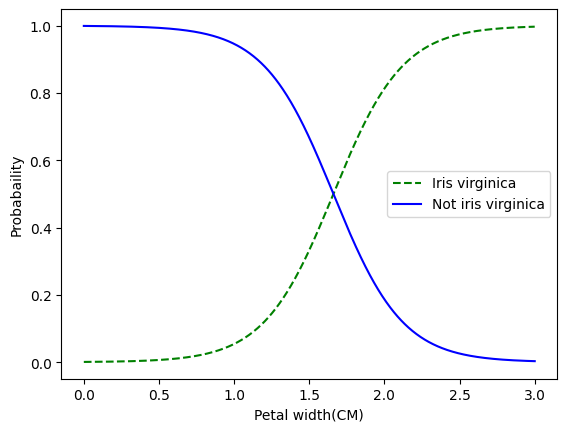

In [137]:
plt.plot(x_new,y_prob[:,-1],'g--',label="Iris virginica" )
plt.plot(x_new,y_prob[:,0],'b-',label="Not iris virginica")
plt.xlabel("Petal width(CM)")
plt.ylabel("Probabaility")
plt.legend()
plt.show()